# 막대그래프(1) 석탄

In [1]:
import os
import random
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

plt.rc('font', family='AppleGothic')  # for windows: family='Malgun Gothic'
plt.rc('axes', unicode_minus=False)  # 마이너스 부호 깨짐 방지
sns.set_theme(style="whitegrid", font="AppleGothic")

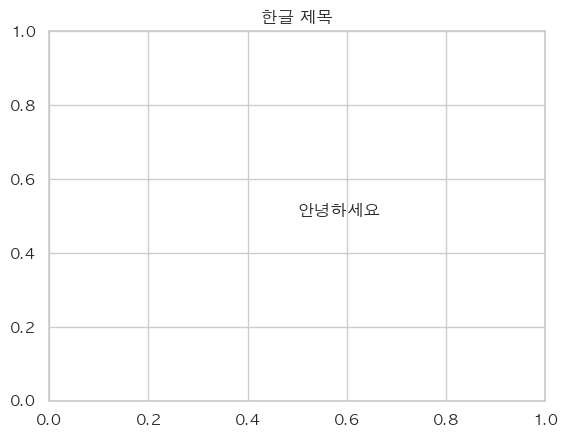

In [2]:
import matplotlib.font_manager as fm

font_path = '/System/Library/Fonts/Supplemental/AppleGothic.ttf' # Replace with the actual path
font_properties = fm.FontProperties(fname=font_path)

plt.text(0.5, 0.5, '안녕하세요', fontproperties=font_properties)
plt.title('한글 제목', fontproperties=font_properties)
plt.show()


In [3]:
output_dataset = pd.read_excel('data/combined_scenario_data.xlsx')

print(output_dataset.head())

   Sector Code       Sector Name          2026           2027           2028  \
0          612               유연탄 -80108.418598 -146261.284150 -146261.284150   
1          622         천연가스(LNG) -15053.798323  -27485.099726  -27485.099726   
2          621                원유  -9365.185676  -17098.878086  -17098.878086   
3         1610              석탄제품  -4263.332424   -7783.956868   -7783.956868   
4         7300  장비·용품 및 지식재산권 임대  -3068.417533   -5602.291201   -5602.291201   

            2029           2030           2031           2032           2033  \
0 -172722.433048 -397016.370871 -397016.370871 -397016.370871 -522139.067111   
1  -32457.620790  -74606.445646  -74606.445646  -74606.445646  -98119.228294   
2  -20192.355363  -46413.748950  -46413.748950  -46413.748950  -61041.391126   
3   -9192.206788  -21129.024846  -21129.024846  -21129.024846  -27787.995991   
4   -6615.840771  -15207.040838  -15207.040838  -15207.040838  -19999.654169   

   ...           2041          2042   

In [4]:
# Excel 파일의 모든 시트 이름 확인
xl_file = pd.ExcelFile('data/combined_scenario_data.xlsx')
sheet_names = xl_file.sheet_names
print("Available sheets:")
for sheet in sheet_names:
    print(f"  - {sheet}")

# 1610이 포함되고 'indirect', 'import', 'value_added'가 포함된 시트 필터링
target_keywords = ['생산', '부가가치', '수입']
filtered_sheets = [sheet for sheet in sheet_names 
                   if '석탄' in sheet and any(keyword in sheet.lower() for keyword in target_keywords)]

print(f"\nFiltered sheets:")
for sheet in filtered_sheets:
    print(f"  - {sheet}")

Available sheets:
  - 석탄_수입유발
  - 재생에너지_수입유발
  - 재생에너지_취업유발
  - 석탄_취업유발
  - 재생에너지_고용유발
  - 석탄_고용유발
  - 재생에너지_부가가치유발
  - 석탄_부가가치유발
  - 재생에너지_생산유발
  - 석탄_생산유발

Filtered sheets:
  - 석탄_수입유발
  - 석탄_부가가치유발
  - 석탄_생산유발


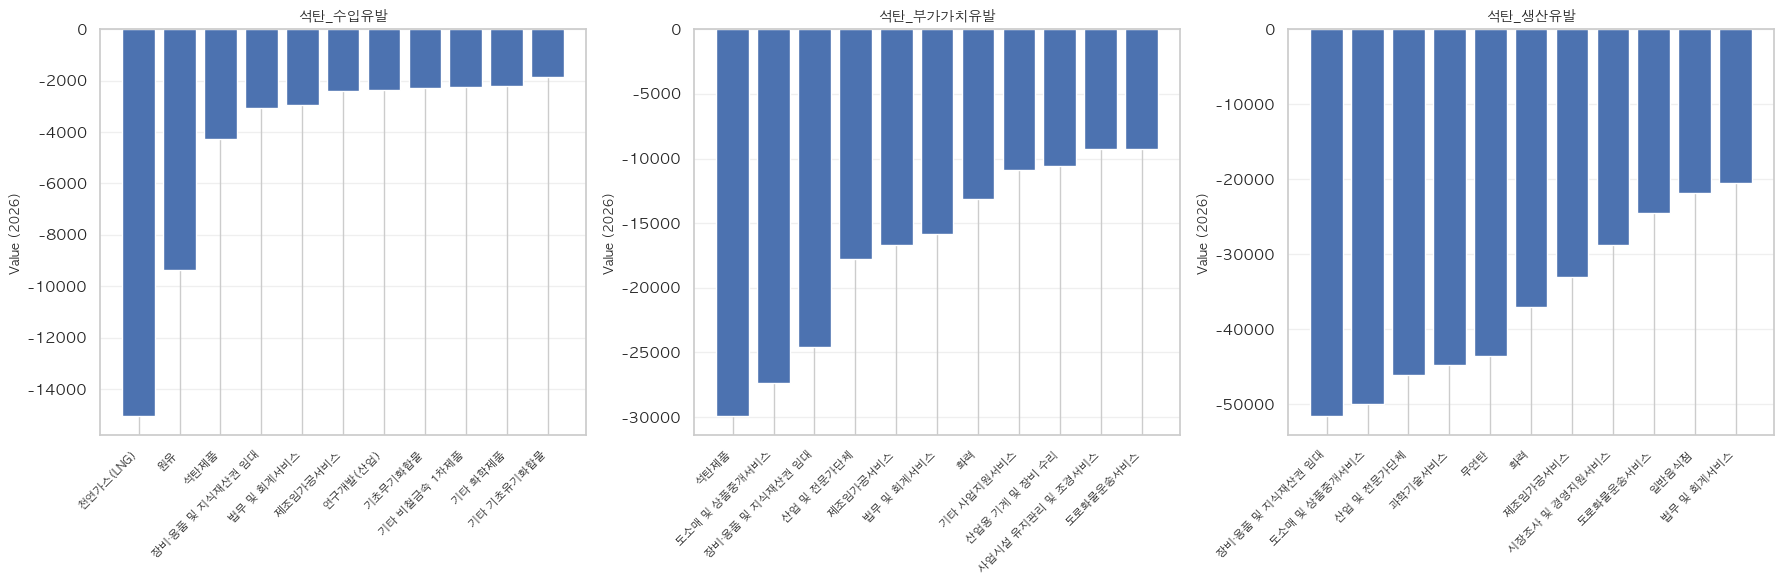

In [5]:
# 각 시트에서 2-12행, 2026년 열 데이터 추출 및 시각화
fig, axes = plt.subplots(1, len(filtered_sheets), figsize=(18, 6))

# 시트가 하나일 경우를 대비해 axes를 리스트로 변환
if len(filtered_sheets) == 1:
    axes = [axes]

for idx, sheet_name in enumerate(filtered_sheets):
    # 데이터 읽기
    df = pd.read_excel('data/combined_scenario_data.xlsx', sheet_name=sheet_name)
    
    # 2-12행 (인덱스 1-11), 2026년 열 추출
    data_subset = df.iloc[1:12]
    sector_names = data_subset['Sector Name'].values
    values_2026 = data_subset['2026'].values
    
    # Column chart 그리기
    axes[idx].bar(range(len(values_2026)), values_2026)
    axes[idx].set_xticks(range(len(sector_names)))
    axes[idx].set_xticklabels(sector_names, rotation=45, ha='right', fontsize=8)
    axes[idx].set_title(sheet_name, fontsize=10)
    axes[idx].set_ylabel('Value (2026)', fontsize=9)
    axes[idx].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('output/aggregated_1610_charts_economics.png', dpi=300, bbox_inches='tight')
plt.show()

In [6]:
# Excel 파일의 모든 시트 이름 확인
xl_file = pd.ExcelFile('data/combined_scenario_data.xlsx')
sheet_names = xl_file.sheet_names
print("Available sheets:")
for sheet in sheet_names:
    print(f"  - {sheet}")

# 1610이 포함되고 'indirect', 'import', 'value_added'가 포함된 시트 필터링
target_keywords = ['고용', '취업']
filtered_sheets = [sheet for sheet in sheet_names 
                   if '석탄' in sheet and any(keyword in sheet.lower() for keyword in target_keywords)]

print(f"\nFiltered sheets:")
for sheet in filtered_sheets:
    print(f"  - {sheet}")

Available sheets:
  - 석탄_수입유발
  - 재생에너지_수입유발
  - 재생에너지_취업유발
  - 석탄_취업유발
  - 재생에너지_고용유발
  - 석탄_고용유발
  - 재생에너지_부가가치유발
  - 석탄_부가가치유발
  - 재생에너지_생산유발
  - 석탄_생산유발

Filtered sheets:
  - 석탄_취업유발
  - 석탄_고용유발


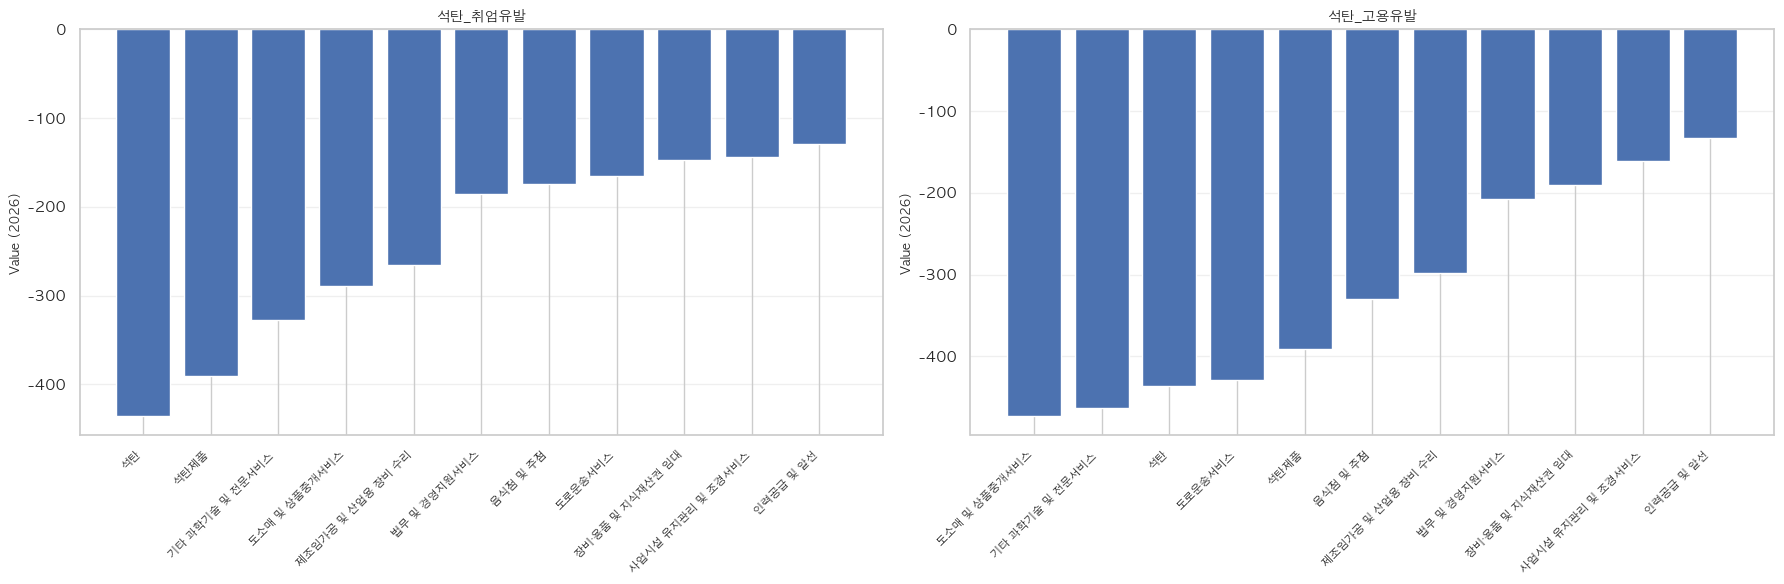

In [7]:
# 각 시트에서 2-12행, 2026년 열 데이터 추출 및 시각화
fig, axes = plt.subplots(1, len(filtered_sheets), figsize=(18, 6))

# 시트가 하나일 경우를 대비해 axes를 리스트로 변환
if len(filtered_sheets) == 1:
    axes = [axes]

for idx, sheet_name in enumerate(filtered_sheets):
    # 데이터 읽기
    df = pd.read_excel('data/combined_scenario_data.xlsx', sheet_name=sheet_name)
    
    # 2-12행 (인덱스 1-11), 2026년 열 추출
    data_subset = df.iloc[1:12]
    sector_names = data_subset['Sector Name'].values
    values_2026 = data_subset['2026'].values
    
    # Column chart 그리기
    axes[idx].bar(range(len(values_2026)), values_2026)
    axes[idx].set_xticks(range(len(sector_names)))
    axes[idx].set_xticklabels(sector_names, rotation=45, ha='right', fontsize=8)
    axes[idx].set_title(sheet_name, fontsize=10)
    axes[idx].set_ylabel('Value (2026)', fontsize=9)
    axes[idx].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('output/aggregated_1610_charts_job.png', dpi=300, bbox_inches='tight')
plt.show()

In [5]:
# 석탄과 재생에너지의 연도별 총 영향 계산
# 각 지표(생산, 수입, 부가가치, 고용, 취업)에 대해 연도별 합계 계산

indicators = {
    '생산': [],
    '수입': [],
    '부가가치': [],
    '고용': [],
    '취업': []
}

# 석탄 데이터
coal_data = {}
for indicator in indicators.keys():
    matching_sheets = [sheet for sheet in sheet_names
                        if '석탄' in sheet and indicator in sheet]
    print(f"석탄 - {indicator}: {matching_sheets}")

    if matching_sheets:
        sheet_name = matching_sheets[0]
        df = pd.read_excel('data/combined_scenario_data.xlsx', sheet_name=sheet_name)

        # 연도 컬럼만 선택 (2026-2050)
        year_columns = [col for col in df.columns if str(col).isdigit()]

        # 각 연도별 총합 계산
        yearly_totals = df[year_columns].sum()
        coal_data[indicator] = yearly_totals

print("\n석탄 데이터:")
coal_df = pd.DataFrame(coal_data)
print(coal_df)

NameError: name 'sheet_names' is not defined

In [ ]:
# 재생에너지 데이터
renewable_data = {}
for indicator in indicators.keys():
    matching_sheets = [sheet for sheet in sheet_names
                        if '재생에너지' in sheet and indicator in sheet]
    print(f"재생에너지 - {indicator}: {matching_sheets}")

    if matching_sheets:
        sheet_name = matching_sheets[0]
        df = pd.read_excel('data/combined_scenario_data.xlsx', sheet_name=sheet_name)

        # 연도 컬럼만 선택 (2026-2050)
        year_columns = [col for col in df.columns if str(col).isdigit()]

        # 각 연도별 총합 계산
        yearly_totals = df[year_columns].sum()
        renewable_data[indicator] = yearly_totals

print("\n재생에너지 데이터:")
renewable_df = pd.DataFrame(renewable_data)
# 2025년 행(인덱스에 2025가 있으면) 삭제
if 2025 in renewable_df.index:
    renewable_df = renewable_df.drop(2025)
print(renewable_df)

재생에너지 - 생산: ['재생에너지_생산유발']
재생에너지 - 수입: ['재생에너지_수입유발']
재생에너지 - 부가가치: ['재생에너지_부가가치유발']
재생에너지 - 고용: ['재생에너지_고용유발']
재생에너지 - 취업: ['재생에너지_취업유발']

재생에너지 데이터:
                생산            수입          부가가치             고용             취업
2025  2.289799e+07  2.704459e+06  1.084145e+07   35329.883764   29054.028844
2026  2.505039e+07  2.958675e+06  1.186054e+07   38650.860386   31785.080867
2027  2.733833e+07  3.228902e+06  1.294380e+07   42180.987323   34688.130607
2028  2.843186e+07  3.358058e+06  1.346156e+07   43868.226816   36075.655831
2029  3.012548e+07  3.558090e+06  1.426343e+07   46481.353677   38224.597609
2030  3.688486e+07  4.356433e+06  1.746378e+07   56910.572070   46801.212636
2031  3.836026e+07  4.530691e+06  1.816233e+07   59186.994953   48673.261141
2032  4.042078e+07  4.774057e+06  1.913792e+07   62366.222090   51287.743475
2033  4.793553e+07  5.661616e+06  2.269590e+07   73960.915246   60822.803132
2034  4.985295e+07  5.888081e+06  2.360374e+07   76919.351856   63255.715258
20

In [10]:
# 결과를 Excel 파일로 저장
with pd.ExcelWriter('output/total_impact_per_year.xlsx') as writer:
    coal_df.to_excel(writer, sheet_name='석탄')
    renewable_df.to_excel(writer, sheet_name='재생에너지')

print("총 영향 데이터가 'output/total_impact_per_year.xlsx'에 저장되었습니다.")

총 영향 데이터가 'output/total_impact_per_year.xlsx'에 저장되었습니다.


In [6]:
# 'output/total_impact_per_year.xlsx'에서 데이터프레임 불러오기

with pd.ExcelFile('output/total_impact_per_year.xlsx') as xls:
    coal_df = pd.read_excel(xls, sheet_name='석탄', index_col=0)
    renewable_df = pd.read_excel(xls, sheet_name='재생에너지', index_col=0)
    total_df = pd.read_excel(xls, sheet_name='통합', index_col=0)

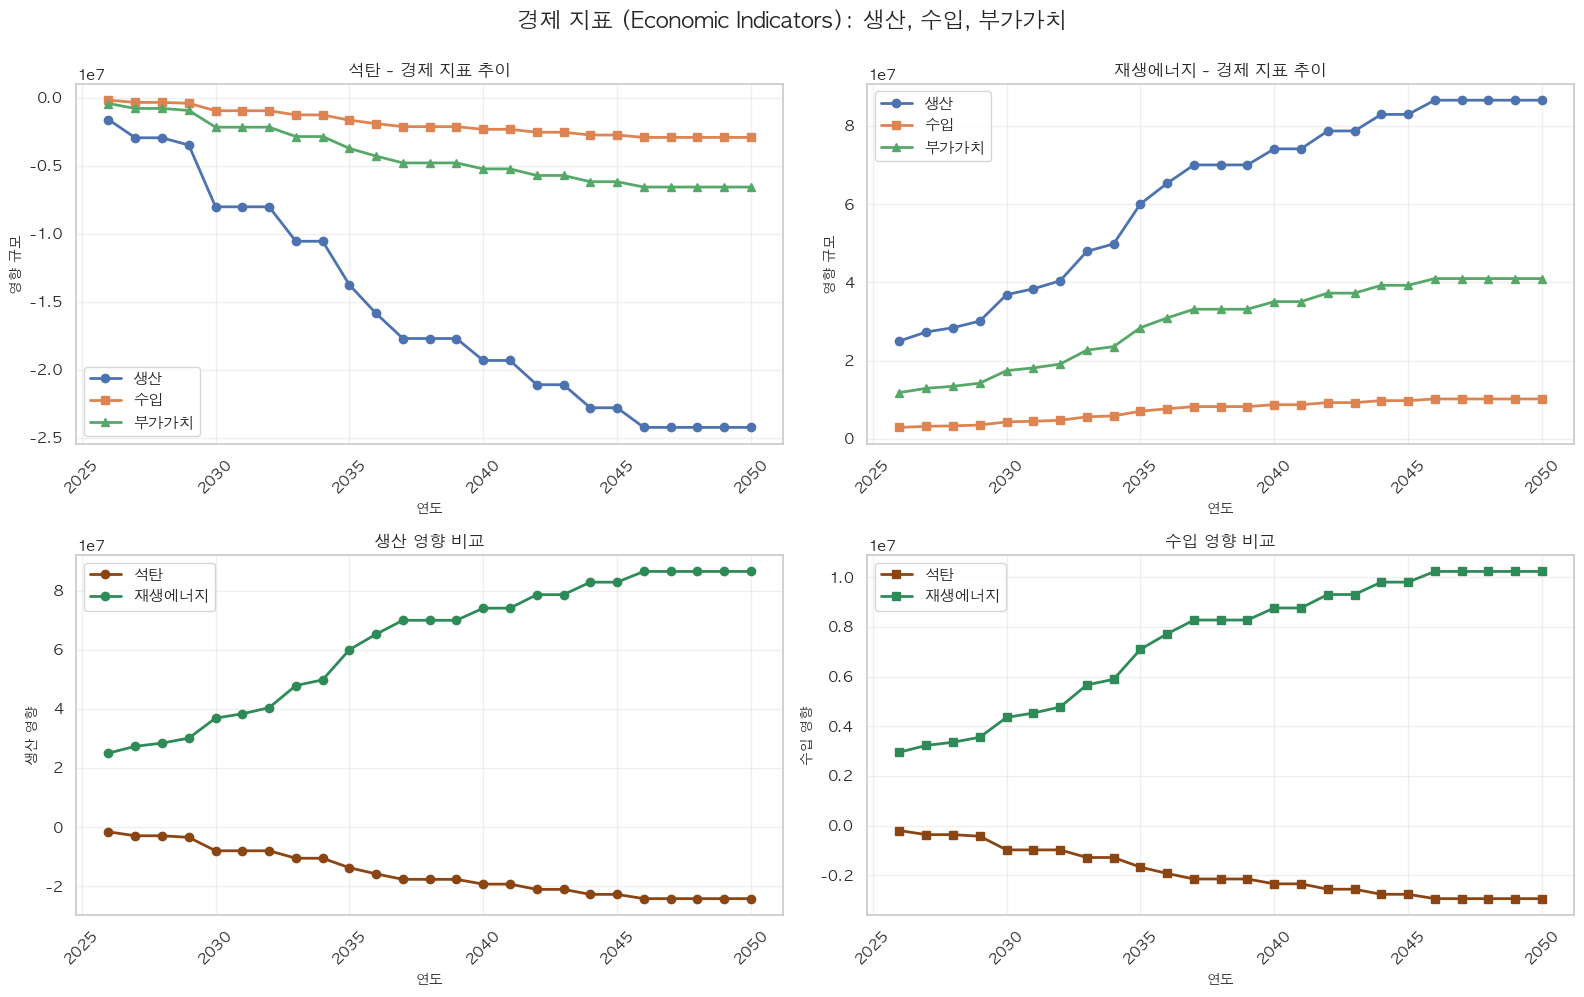

In [7]:
# Economic Indicators 시각화 (생산, 수입, 부가가치)
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# 석탄 - 경제 지표
economic_indicators = ['생산', '수입', '부가가치']
coal_economic = coal_df[economic_indicators]

axes[0, 0].plot(coal_economic.index, coal_economic['생산'], marker='o', linewidth=2, label='생산')
axes[0, 0].plot(coal_economic.index, coal_economic['수입'], marker='s', linewidth=2, label='수입')
axes[0, 0].plot(coal_economic.index, coal_economic['부가가치'], marker='^', linewidth=2, label='부가가치')
axes[0, 0].set_title('석탄 - 경제 지표 추이', fontsize=12, fontweight='bold')
axes[0, 0].set_xlabel('연도', fontsize=10)
axes[0, 0].set_ylabel('영향 규모', fontsize=10)
axes[0, 0].legend(loc='best')
axes[0, 0].grid(alpha=0.3)
axes[0, 0].tick_params(axis='x', rotation=45)

# 재생에너지 - 경제 지표
renewable_economic = renewable_df[economic_indicators]

axes[0, 1].plot(renewable_economic.index, renewable_economic['생산'], marker='o', linewidth=2, label='생산')
axes[0, 1].plot(renewable_economic.index, renewable_economic['수입'], marker='s', linewidth=2, label='수입')
axes[0, 1].plot(renewable_economic.index, renewable_economic['부가가치'], marker='^', linewidth=2, label='부가가치')
axes[0, 1].set_title('재생에너지 - 경제 지표 추이', fontsize=12, fontweight='bold')
axes[0, 1].set_xlabel('연도', fontsize=10)
axes[0, 1].set_ylabel('영향 규모', fontsize=10)
axes[0, 1].legend(loc='best')
axes[0, 1].grid(alpha=0.3)
axes[0, 1].tick_params(axis='x', rotation=45)

# 석탄 vs 재생에너지 - 생산 비교
axes[1, 0].plot(coal_economic.index, coal_economic['생산'], marker='o', linewidth=2, label='석탄', color='#8B4513')
axes[1, 0].plot(renewable_economic.index, renewable_economic['생산'], marker='o', linewidth=2, label='재생에너지', color='#2E8B57')
axes[1, 0].set_title('생산 영향 비교', fontsize=12, fontweight='bold')
axes[1, 0].set_xlabel('연도', fontsize=10)
axes[1, 0].set_ylabel('생산 영향', fontsize=10)
axes[1, 0].legend(loc='best')
axes[1, 0].grid(alpha=0.3)
axes[1, 0].tick_params(axis='x', rotation=45)

# 석탄 vs 재생에너지 - 수입 비교
axes[1, 1].plot(coal_economic.index, coal_economic['수입'], marker='s', linewidth=2, label='석탄', color='#8B4513')
axes[1, 1].plot(renewable_economic.index, renewable_economic['수입'], marker='s', linewidth=2, label='재생에너지', color='#2E8B57')
axes[1, 1].set_title('수입 영향 비교', fontsize=12, fontweight='bold')
axes[1, 1].set_xlabel('연도', fontsize=10)
axes[1, 1].set_ylabel('수입 영향', fontsize=10)
axes[1, 1].legend(loc='best')
axes[1, 1].grid(alpha=0.3)
axes[1, 1].tick_params(axis='x', rotation=45)

plt.suptitle('경제 지표 (Economic Indicators): 생산, 수입, 부가가치', fontsize=16, fontweight='bold', y=0.995)
plt.tight_layout()
plt.savefig('output/economic_indicators_trends.png', dpi=300, bbox_inches='tight')
plt.show()

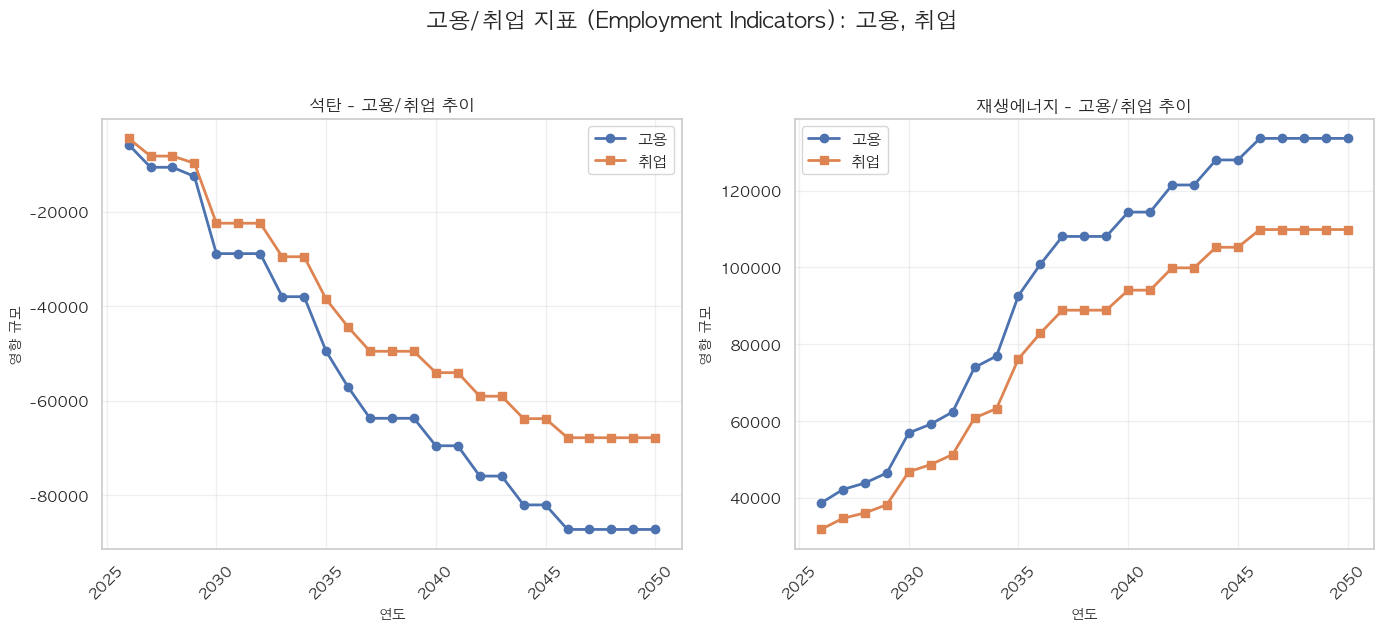

In [8]:
# 고용/취업 지표 시각화 (고용, 취업)
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# 석탄 - 고용/취업 지표
employment_indicators = ['고용', '취업']
coal_employment = coal_df[employment_indicators]

axes[0].plot(coal_employment.index, coal_employment['고용'], marker='o', linewidth=2, label='고용')
axes[0].plot(coal_employment.index, coal_employment['취업'], marker='s', linewidth=2, label='취업')
axes[0].set_title('석탄 - 고용/취업 추이', fontsize=12, fontweight='bold')
axes[0].set_xlabel('연도', fontsize=10)
axes[0].set_ylabel('영향 규모', fontsize=10)
axes[0].legend(loc='best')
axes[0].grid(alpha=0.3)
axes[0].tick_params(axis='x', rotation=45)

# 재생에너지 - 고용/취업 지표
renewable_employment = renewable_df[employment_indicators]

axes[1].plot(renewable_employment.index, renewable_employment['고용'], marker='o', linewidth=2, label='고용')
axes[1].plot(renewable_employment.index, renewable_employment['취업'], marker='s', linewidth=2, label='취업')
axes[1].set_title('재생에너지 - 고용/취업 추이', fontsize=12, fontweight='bold')
axes[1].set_xlabel('연도', fontsize=10)
axes[1].set_ylabel('영향 규모', fontsize=10)
axes[1].legend(loc='best')
axes[1].grid(alpha=0.3)
axes[1].tick_params(axis='x', rotation=45)

plt.suptitle('고용/취업 지표 (Employment Indicators): 고용, 취업', fontsize=16, fontweight='bold', y=1.05)
plt.tight_layout()
plt.savefig('output/employment_indicators_trends.png', dpi=300, bbox_inches='tight')
plt.show()

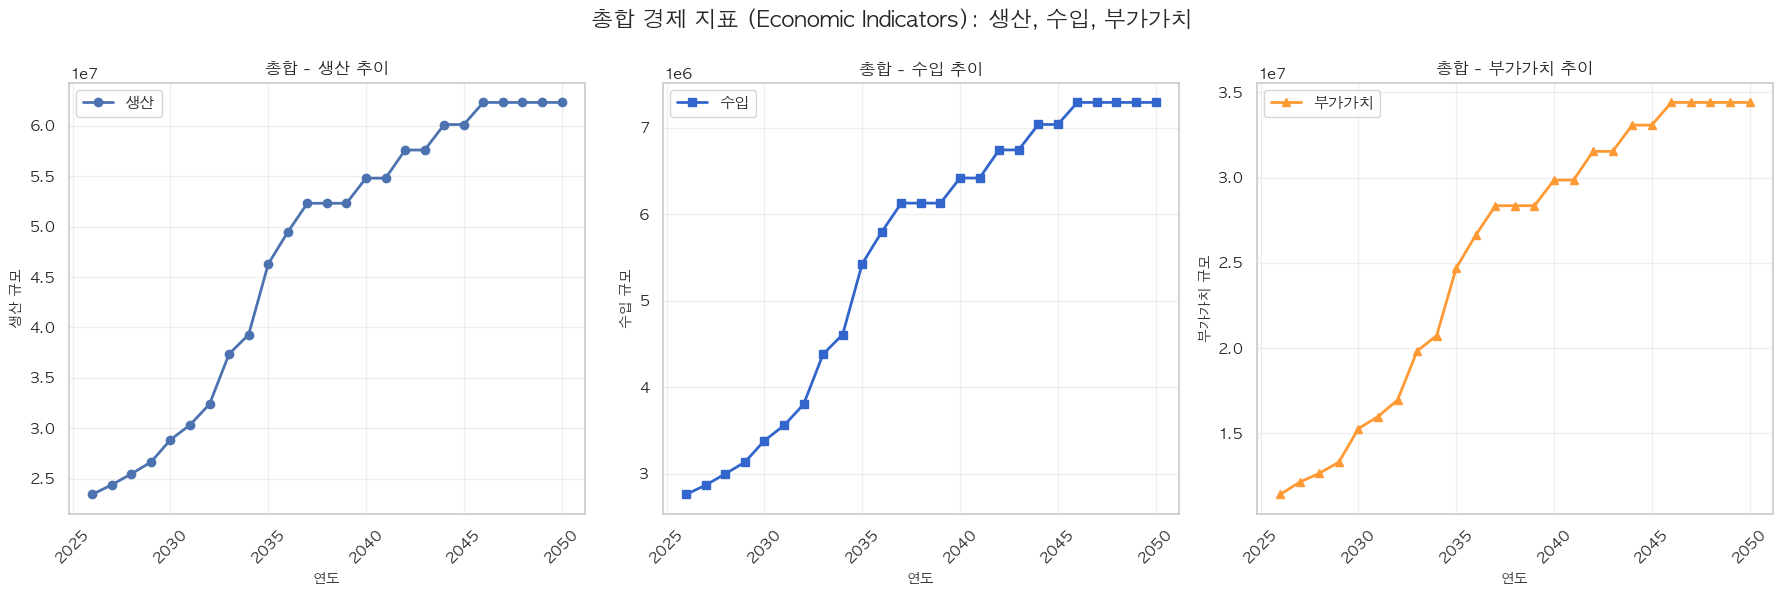

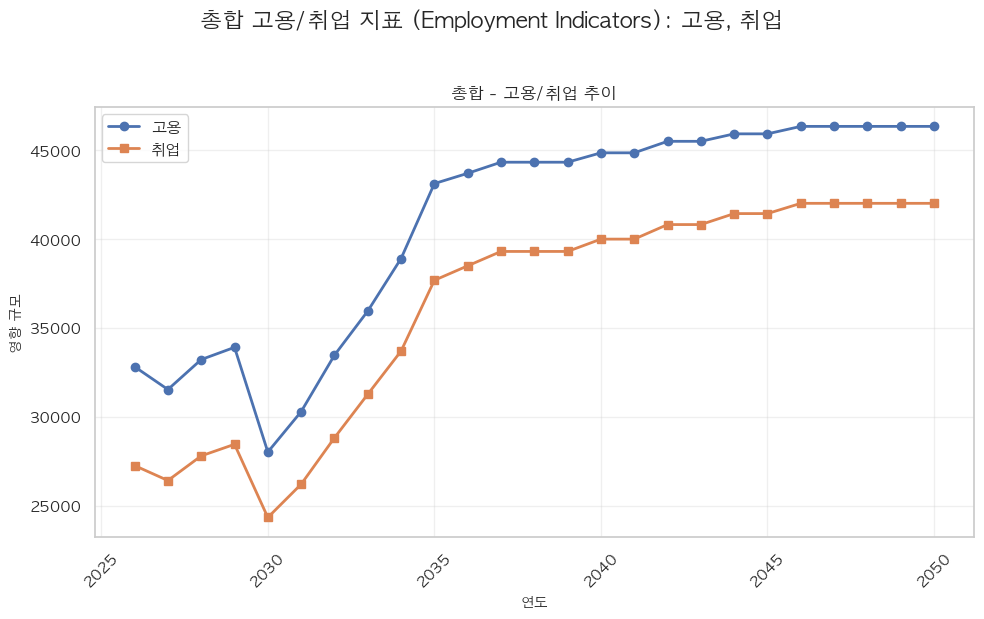

In [9]:
# total_df를 활용한 Economic/Employment Indicators 시각화

# Economic Indicators 시각화 (생산, 수입, 부가가치)
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

economic_indicators = ['생산', '수입', '부가가치']
total_economic = total_df[economic_indicators]

# 생산
axes[0].plot(total_economic.index, total_economic['생산'], marker='o', linewidth=2, label='생산')
axes[0].set_title('총합 - 생산 추이', fontsize=12, fontweight='bold')
axes[0].set_xlabel('연도', fontsize=10)
axes[0].set_ylabel('생산 규모', fontsize=10)
axes[0].legend(loc='best')
axes[0].grid(alpha=0.3)
axes[0].tick_params(axis='x', rotation=45)

# 수입
axes[1].plot(total_economic.index, total_economic['수입'], marker='s', linewidth=2, label='수입', color="#3366CC")
axes[1].set_title('총합 - 수입 추이', fontsize=12, fontweight='bold')
axes[1].set_xlabel('연도', fontsize=10)
axes[1].set_ylabel('수입 규모', fontsize=10)
axes[1].legend(loc='best')
axes[1].grid(alpha=0.3)
axes[1].tick_params(axis='x', rotation=45)

# 부가가치
axes[2].plot(total_economic.index, total_economic['부가가치'], marker='^', linewidth=2, label='부가가치', color="#FF9933")
axes[2].set_title('총합 - 부가가치 추이', fontsize=12, fontweight='bold')
axes[2].set_xlabel('연도', fontsize=10)
axes[2].set_ylabel('부가가치 규모', fontsize=10)
axes[2].legend(loc='best')
axes[2].grid(alpha=0.3)
axes[2].tick_params(axis='x', rotation=45)

plt.suptitle('총합 경제 지표 (Economic Indicators): 생산, 수입, 부가가치', fontsize=16, fontweight='bold', y=0.99)
plt.tight_layout()
plt.savefig('output/total_economic_indicators_trends.png', dpi=300, bbox_inches='tight')
plt.show()

# 고용/취업 지표 시각화 (고용, 취업)
fig, ax = plt.subplots(1, 1, figsize=(10, 6))

employment_indicators = ['고용', '취업']
total_employment = total_df[employment_indicators]

ax.plot(total_employment.index, total_employment['고용'], marker='o', linewidth=2, label='고용')
ax.plot(total_employment.index, total_employment['취업'], marker='s', linewidth=2, label='취업')
ax.set_title('총합 - 고용/취업 추이', fontsize=12, fontweight='bold')
ax.set_xlabel('연도', fontsize=10)
ax.set_ylabel('영향 규모', fontsize=10)
ax.legend(loc='best')
ax.grid(alpha=0.3)
ax.tick_params(axis='x', rotation=45)

plt.suptitle('총합 고용/취업 지표 (Employment Indicators): 고용, 취업', fontsize=16, fontweight='bold', y=1.03)
plt.tight_layout()
plt.savefig('output/total_employment_indicators_trends.png', dpi=300, bbox_inches='tight')
plt.show()

In [42]:
fullsector_total_prod = pd.read_excel('data/full sector_total.xlsx', sheet_name= 'total_production')

print(fullsector_total_prod.head())

   code sector name          2026          2027          2028          2029  \
0  0111           벼   7998.775696   7987.608553   8380.867178   8656.344855   
1  0112     맥류 및 잡곡    875.010306    924.489149    964.495462   1012.765839   
2  0113          콩류  22534.072309  24566.102820  25551.341240  27065.503969   
3  0114         감자류    894.442655    895.691865    939.518538    971.216616   
4  0121          채소   6963.574337   6829.161857   7178.936089   7374.160886   

           2030          2031          2032          2033  ...          2041  \
0   8259.584252   8790.168641   9531.176956  10656.274925  ...  14620.671635   
1   1144.015043   1197.991546   1273.374535   1483.564950  ...   2218.184553   
2  33056.030752  34385.314054  36241.776480  42956.841137  ...  66373.543643   
3    935.454760    994.585690   1077.167296   1207.270427  ...   1665.406003   
4   6599.217016   7071.132276   7730.203934   8495.450776  ...  11206.650485   

           2042          2043          2044 

In [36]:
fullsector_total_job = pd.read_excel('data/full sector_total.xlsx', sheet_name= 'total_job')

print(fullsector_total_job.head())

   code sector name        2026        2027        2028        2029  \
0    11   곡물 및 식량작물  155.800561  131.816392  140.888902  137.753577   
1    12     채소 및 과실  212.106326  192.525241  204.099641  204.506542   
2    19        기타작물   46.394957   41.148234   43.737231   43.481540   
3    21     낙농 및 축우   12.989412   11.045096   11.798203   11.556583   
4    29       기타 축산   16.127475   13.613813   14.554782   14.219154   

         2030        2031        2032        2033  ...        2041  \
0   48.154484   60.395111   77.490236   58.569541  ...   -5.283273   
1  127.552993  143.169169  164.978549  161.678112  ...  152.333815   
2   23.329531   26.822603   31.700991   29.323320  ...   21.559379   
3    4.276996    5.293088    6.712151    5.229698  ...    0.234361   
4    4.837730    6.107285    7.880331    5.868563  ...   -0.924927   

         2042        2043        2044        2045        2046        2047  \
0  -24.529429  -24.529429  -43.884770  -43.884770  -60.031419  -60.031419  

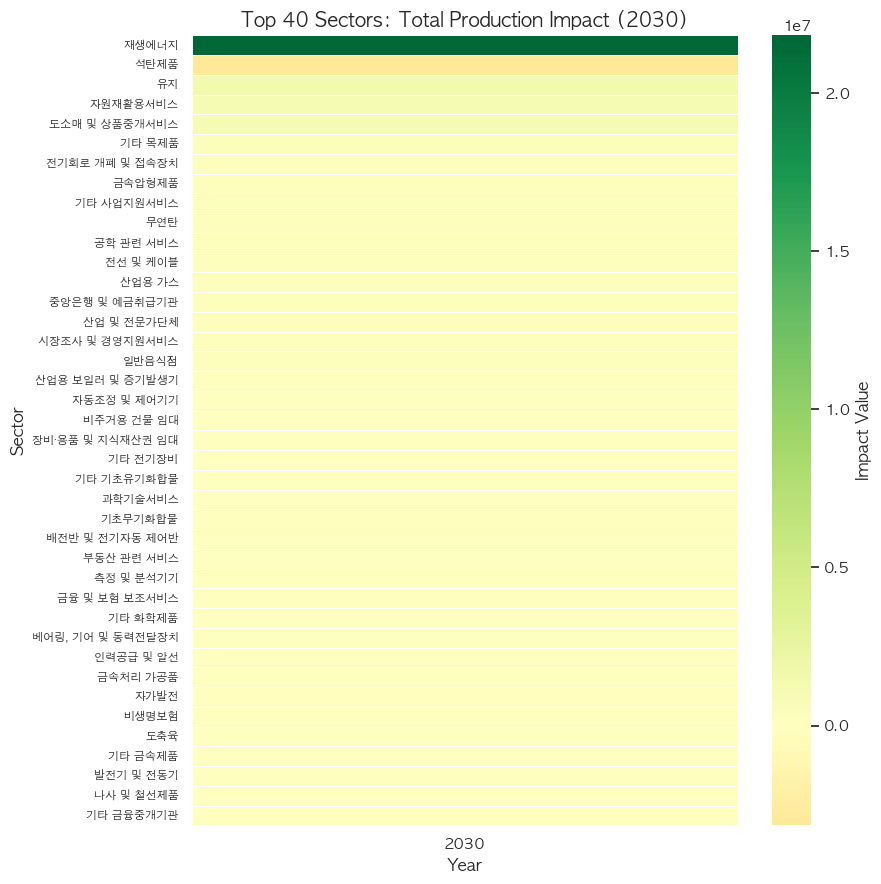

In [39]:
# Heatmap for fullsector_total_prod - Year 2030 only, but only for top 40 sectors by absolute impact
selected_year = [2030]
heatmap_data = fullsector_total_prod[selected_year].copy()
heatmap_data.index = fullsector_total_prod['sector name']

# Get top 40 sectors by absolute value for year 2030
heatmap_data['abs_value'] = heatmap_data[2030].abs()
top_heatmap_data = heatmap_data.sort_values('abs_value', ascending=False).iloc[:40]
top_heatmap_data = top_heatmap_data.drop(columns=['abs_value'])

fig, ax = plt.subplots(figsize=(9,9))

sns.heatmap(
    top_heatmap_data,
    annot=False,
    cmap='RdYlGn',
    center=0,
    cbar_kws={'label': 'Impact Value'},
    ax=ax,
    linewidths=0.5,
    xticklabels=True,
    yticklabels=True
)
ax.set_title('Top 40 Sectors: Total Production Impact (2030)', fontsize=14, fontweight='bold')
ax.set_xlabel('Year', fontsize=12)
ax.set_ylabel('Sector', fontsize=12)
ax.tick_params(axis='y', labelsize=8)

plt.tight_layout()
plt.savefig('output/fullsector_prod_heatmap_2030_top40.png', dpi=300, bbox_inches='tight')
plt.show()

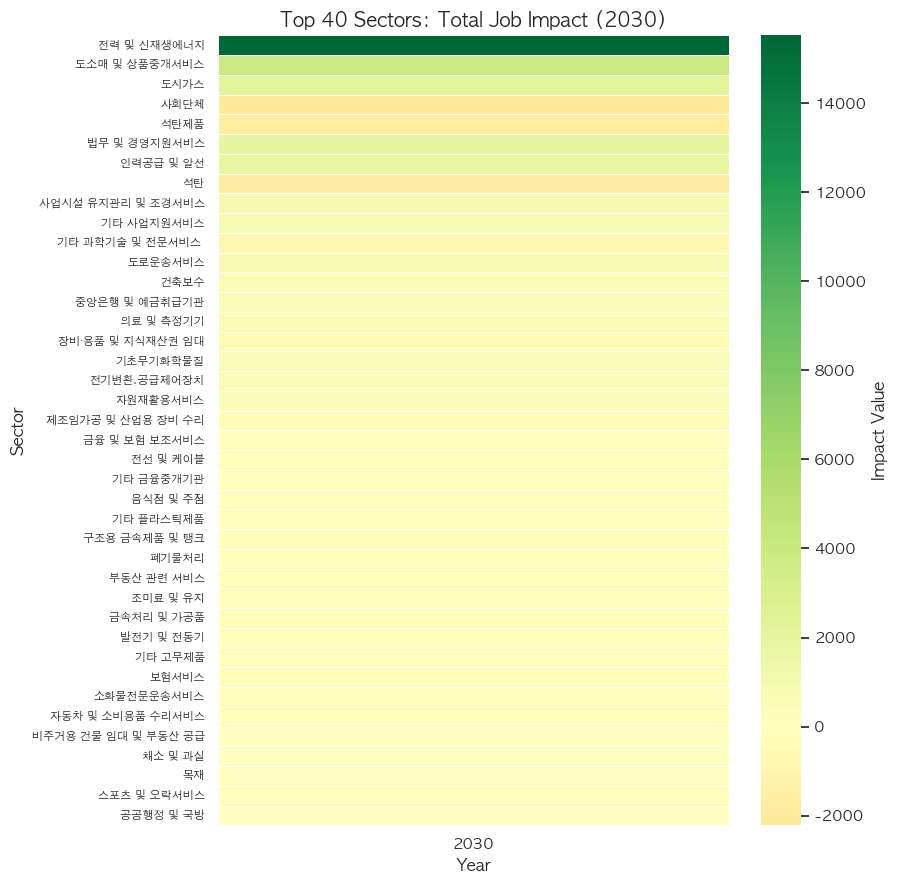

In [41]:
# Heatmap for fullsector_total_prod - Year 2030 only, but only for top 40 sectors by absolute impact
selected_year = [2030]
heatmap_data = fullsector_total_job[selected_year].copy()
heatmap_data.index = fullsector_total_job['sector name']

# Get top 40 sectors by absolute value for year 2030
heatmap_data['abs_value'] = heatmap_data[2030].abs()
top_heatmap_data = heatmap_data.sort_values('abs_value', ascending=False).iloc[:40]
top_heatmap_data = top_heatmap_data.drop(columns=['abs_value'])

fig, ax = plt.subplots(figsize=(9,9))

sns.heatmap(
    top_heatmap_data,
    annot=False,
    cmap='RdYlGn',
    center=0,
    cbar_kws={'label': 'Impact Value'},
    ax=ax,
    linewidths=0.5,
    xticklabels=True,
    yticklabels=True
)
ax.set_title('Top 40 Sectors: Total Job Impact (2030)', fontsize=14, fontweight='bold')
ax.set_xlabel('Year', fontsize=12)
ax.set_ylabel('Sector', fontsize=12)
ax.tick_params(axis='y', labelsize=8)

plt.tight_layout()
plt.savefig('output/fullsector_job_heatmap_2030_top40.png', dpi=300, bbox_inches='tight')
plt.show()

In [44]:
sankey_total_prod = pd.read_excel('data/full sector_total.xlsx', sheet_name= 'sankey_production')

print(sankey_total_prod.head())

   code sector name     2020          2026          2027          2028  \
0   111           벼  8382325  8.390324e+06  8.390313e+06  8.390706e+06   
1   112     맥류 및 잡곡   280543  2.814180e+05  2.814675e+05  2.815075e+05   
2   113          콩류   274189  2.967231e+05  2.987551e+05  2.997403e+05   
3   114         감자류   747911  7.488054e+05  7.488067e+05  7.488505e+05   
4   121          채소  5283053  5.290017e+06  5.289882e+06  5.290232e+06   

           2029          2030          2031          2032  ...          2041  \
0  8.390981e+06  8.390585e+06  8.391115e+06  8.391856e+06  ...  8.396946e+06   
1  2.815558e+05  2.816870e+05  2.817410e+05  2.818164e+05  ...  2.827612e+05   
2  3.012545e+05  3.072450e+05  3.085743e+05  3.104308e+05  ...  3.405625e+05   
3  7.488822e+05  7.488465e+05  7.489056e+05  7.489882e+05  ...  7.495764e+05   
4  5.290427e+06  5.289652e+06  5.290124e+06  5.290783e+06  ...  5.294260e+06   

           2042          2043          2044          2045          2046  \

In [47]:
# Sankey diagram for sankey_total_prod (2020 to 2030, Top 40 sectors)
import plotly.graph_objects as go
import IPython
import os

# Read sankey_total_prod data
sankey_total_prod = pd.read_excel('data/full sector_total.xlsx', sheet_name='total_production')

# Extract top 40 sectors based on absolute values in 2030
sankey_data = sankey_total_prod.copy()
sankey_data['abs_2030'] = sankey_data[2030].abs()
top_40_sectors = sankey_data.nlargest(40, 'abs_2030')

# Prepare data for Sankey
sources = []
targets = []
values = []
colors = []

# Create labels: sector names for 2020 and 2030
sector_names = top_40_sectors['sector name'].tolist()
labels_2020 = [f"{name} (2020)" for name in sector_names]
labels_2030 = [f"{name} (2030)" for name in sector_names]
labels = labels_2020 + labels_2030

# Create flows from 2020 to 2030
for idx, row in top_40_sectors.iterrows():
    source_idx = sector_names.index(row['sector name'])
    target_idx = len(sector_names) + sector_names.index(row['sector name'])

    # Use 2030 value as flow width (take absolute value)
    value = abs(row[2030])

    # Color flows based on positive (green) or negative (red) impact
    if row[2030] > 0:
        color = "rgba(0, 200, 0, 0.4)"
    else:
        color = "rgba(200, 0, 0, 0.4)"

    sources.append(source_idx)
    targets.append(target_idx)
    values.append(value)
    colors.append(color)

# Create Sankey diagram
fig = go.Figure(data=[go.Sankey(
    node=dict(
        pad=15,
        thickness=20,
        line=dict(color="black", width=0.5),
        label=labels,
        color="lightblue"
    ),
    link=dict(
        source=sources,
        target=targets,
        value=values,
        color=colors
    )
)])

fig.update_layout(
    title_text="Production Impact Flow: 2020 → 2030 (Top 40 Sectors)",
    font_size=10,
    height=1400,
    width=1600
)

# Save figure as a static image (JPG)
# Ensure the output directory exists
output_dir = "output"
if not os.path.exists(output_dir):
    os.makedirs(output_dir)

img_path = os.path.join(output_dir, "sankey_prod_2020_2030.jpg")

try:
    fig.write_image(img_path, format="jpg")
    print(f"Sankey diagram saved to '{img_path}'")
    # Show a download link in Jupyter/IPython
    from IPython.display import display, FileLink
    display(FileLink(img_path))
except ValueError as e:
    print("Image export failed. Please ensure 'kaleido' is installed. Run:")
    print("!pip install -U kaleido")
    print(str(e))

# (Optional) Still show interactive HTML and save as before
fig.write_html('output/sankey_prod_2020_2030.html')
fig.show()

Image export failed. Please ensure 'kaleido' is installed. Run:
!pip install -U kaleido

Image export using the "kaleido" engine requires the kaleido package,
which can be installed using pip:
    $ pip install -U kaleido

